In [1]:
%pip install pyyaml pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import yaml
import pandas as pd

base_folder = "data"  #root folder

all_data = []

for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.endswith(".yaml") or file.endswith(".yml"):
            file_path = os.path.join(root, file)
            
            with open(file_path, "r") as f:
                data = yaml.safe_load(f)
                
                if isinstance(data, list):
                    all_data.extend(data)
                else:
                    all_data.append(data)

# Convert to DataFrame
df = pd.DataFrame(all_data)

print(df)

           Ticker    close                 date    high      low    month  \
0            SBIN   602.95  2023-10-03 05:30:00   604.9   589.60  2023-10   
1      BAJFINANCE  7967.60  2023-10-03 05:30:00  7975.5  7755.00  2023-10   
2           TITAN  3196.25  2023-10-03 05:30:00  3212.5  3114.40  2023-10   
3             ITC   439.75  2023-10-03 05:30:00   442.9   439.25  2023-10   
4             TCS  3513.85  2023-10-03 05:30:00  3534.2  3480.10  2023-10   
...           ...      ...                  ...     ...      ...      ...   
14195    HINDALCO   652.10  2024-11-22 05:30:00   657.3   647.40  2024-11   
14196  HEROMOTOCO  4794.10  2024-11-22 05:30:00  4808.4  4742.00  2024-11   
14197    AXISBANK  1142.40  2024-11-22 05:30:00  1147.9  1127.55  2024-11   
14198    HDFCBANK  1745.60  2024-11-22 05:30:00  1754.3  1729.55  2024-11   
14199  BAJAJ-AUTO  9481.65  2024-11-22 05:30:00  9602.9  9444.10  2024-11   

          open    volume  
0       596.60  15322196  
1      7780.80    944

In [5]:
df.to_csv("combined_stock_data.csv", index=False)

Separate .yaml stock files were combined and it was changed to complete .CSV file

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14200 entries, 0 to 14199
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  14200 non-null  object 
 1   close   14200 non-null  float64
 2   date    14200 non-null  object 
 3   high    14200 non-null  float64
 4   low     14200 non-null  float64
 5   month   14200 non-null  object 
 6   open    14200 non-null  float64
 7   volume  14200 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 887.6+ KB


In [ ]:
df

,Ticker,close,date,high,low,month,open,volume
0,SBIN,602.95,2023-10-03 05:30:00,604.9,589.60,2023-10,596.60,15322196
1,BAJFINANCE,7967.60,2023-10-03 05:30:00,7975.5,7755.00,2023-10,7780.80,944555
2,TITAN,3196.25,2023-10-03 05:30:00,3212.5,3114.40,2023-10,3148.80,1007308
3,ITC,439.75,2023-10-03 05:30:00,442.9,439.25,2023-10,441.00,7481883
4,TCS,3513.85,2023-10-03 05:30:00,3534.2,3480.10,2023-10,3534.20,1948148
...,...,...,...,...,...,...,...,...
14195,HINDALCO,652.10,2024-11-22 05:30:00,657.3,647.40,2024-11,652.95,3586402
14196,HEROMOTOCO,4794.10,2024-11-22 05:30:00,4808.4,4742.00,2024-11,4778.40,394712
14197,AXISBANK,1142.40,2024-11-22 05:30:00,1147.9,1127.55,2024-11,1136.65,16687505
14198,HDFCBANK,1745.60,2024-11-22 05:30:00,1754.3,1729.55,2024-11,1743.55,12386806


In [15]:
df['date']=pd.to_datetime(df['date']).dt.date

In [16]:
df

,Ticker,close,date,high,low,month,open,volume
0,SBIN,602.95,2023-10-03,604.9,589.60,2023-10,596.60,15322196
1,BAJFINANCE,7967.60,2023-10-03,7975.5,7755.00,2023-10,7780.80,944555
2,TITAN,3196.25,2023-10-03,3212.5,3114.40,2023-10,3148.80,1007308
3,ITC,439.75,2023-10-03,442.9,439.25,2023-10,441.00,7481883
4,TCS,3513.85,2023-10-03,3534.2,3480.10,2023-10,3534.20,1948148
...,...,...,...,...,...,...,...,...
14195,HINDALCO,652.10,2024-11-22,657.3,647.40,2024-11,652.95,3586402
14196,HEROMOTOCO,4794.10,2024-11-22,4808.4,4742.00,2024-11,4778.40,394712
14197,AXISBANK,1142.40,2024-11-22,1147.9,1127.55,2024-11,1136.65,16687505
14198,HDFCBANK,1745.60,2024-11-22,1754.3,1729.55,2024-11,1743.55,12386806


In [17]:
Unique_Tickers= df['Ticker'].unique()

for ticker in Unique_Tickers:
    a=df[df['Ticker']==ticker]
    a.to_csv(f"{ticker}.csv",index=False)

The file was splitted into 50 separate CSV files based on the Ticker name

In [18]:
import pandas as pd
import os

folder_path = "Ticker Files"   # path where 50 CSV files are stored

dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        dfs.append(df)

# Combine all into one DataFrame
df = pd.concat(dfs, ignore_index=True)

df

,Ticker,close,date,high,low,month,open,volume
0,ADANIENT,2387.25,2023-10-03,2424.90,2372.00,2023-10,2418.00,2019899
1,ADANIENT,2464.95,2023-10-04,2502.75,2392.25,2023-10,2402.20,2857377
2,ADANIENT,2466.35,2023-10-05,2486.50,2446.40,2023-10,2477.95,1132455
3,ADANIENT,2478.10,2023-10-06,2514.95,2466.05,2023-10,2466.35,1510035
4,ADANIENT,2442.60,2023-10-09,2459.70,2411.30,2023-10,2440.00,1408224
...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14,574.55,564.20,2024-11,568.95,4891760
14196,WIPRO,552.85,2024-11-18,566.70,540.30,2024-11,566.70,7644882
14197,WIPRO,562.00,2024-11-19,569.80,554.70,2024-11,556.00,6459889
14198,WIPRO,557.15,2024-11-21,567.60,555.30,2024-11,562.00,5836304


In [19]:
df = df.sort_values(by=["Ticker", "date"])

# Get first and last price per stock
yearly = df.groupby("Ticker").agg(
    first_price=("close", "first"),
    last_price=("close", "last")
)

yearly.head()

,first_price,last_price
Ticker,,
ADANIENT,2387.25,2228.00
ADANIPORTS,831.40,1136.75
APOLLOHOSP,5118.95,6935.10
ASIANPAINT,3166.85,2472.20
AXISBANK,1041.05,1142.40


In [20]:
yearly["yearly_return"] = ((yearly["last_price"] - yearly["first_price"]) / yearly["first_price"]) * 100

print(yearly.head())

            first_price  last_price  yearly_return
Ticker                                            
ADANIENT        2387.25     2228.00      -6.670856
ADANIPORTS       831.40     1136.75      36.727207
APOLLOHOSP      5118.95     6935.10      35.478956
ASIANPAINT      3166.85     2472.20     -21.935046
AXISBANK        1041.05     1142.40       9.735363


In [21]:
#Top 10 Green Stocks
top_10_green = yearly.sort_values(by="yearly_return", ascending=False).head(10)

print(top_10_green)

            first_price  last_price  yearly_return
Ticker                                            
TRENT           2059.10     6652.80     223.092613
BEL              139.20      280.85     101.760057
M&M             1537.40     3012.95      95.976974
BAJAJ-AUTO      5016.45     9481.65      89.011153
BHARTIARTL       925.30     1569.30      69.599049
POWERGRID        199.55      336.95      68.854924
BPCL             170.68      285.85      67.477150
HEROMOTOCO      3015.60     4794.10      58.976655
SUNPHARMA       1141.45     1795.30      57.282404
HCLTECH         1238.70     1898.40      53.257447


In [22]:
#Top 10 Loss Stocks
top_10_loss = yearly.sort_values(by="yearly_return", ascending=True).head(10)

print(top_10_loss)

            first_price  last_price  yearly_return
Ticker                                            
INDUSINDBK      1435.40      998.20     -30.458409
ASIANPAINT      3166.85     2472.20     -21.935046
BAJFINANCE      7967.60     6683.95     -16.110874
ADANIENT        2387.25     2228.00      -6.670856
HINDUNILVR      2468.90     2445.25      -0.957916
NESTLEIND       2231.52     2247.30       0.707141
KOTAKBANK       1727.05     1761.45       1.991836
BAJAJFINSV      1561.05     1600.85       2.549566
TITAN           3196.25     3308.70       3.518185
MARUTI         10346.90    11063.60       6.926712


In [23]:
#Calculate the overall number of green vs. red stocks.
green_stocks=(yearly["yearly_return"]>0).sum()
red_stocks=(yearly["yearly_return"]<0).sum()

print("Green Stocks", green_stocks)
print("Red Stocks", red_stocks)

Green Stocks 45
Red Stocks 5


In [24]:
#Calculate the average price across all stocks.
Avg_price=df["close"].mean()

print("Average Price", Avg_price)

Average Price 2449.415379577465


In [25]:
#Calculate the average Volume across all stocks.
Avg_volume=df["volume"].mean()

print("Average Volume", Avg_volume)

Average Volume 6833474.649154929


In [26]:
#Summary
summary = {
    "Total Stocks": len(yearly),
    "Green Stocks": green_stocks,
    "Red Stocks": red_stocks,
    "Avg Price": Avg_price,
    "Avg Volume": Avg_volume
}

print(summary)

{'Total Stocks': 50, 'Green Stocks': np.int64(45), 'Red Stocks': np.int64(5), 'Avg Price': np.float64(2449.415379577465), 'Avg Volume': np.float64(6833474.649154929)}


**1. Volatility Analysis:**

In [27]:
import pandas as pd

# Ensure correct order
df = df.sort_values(by=["Ticker", "date"])

# Calculate previous close
df["prev_close"] = df.groupby("Ticker")["close"].shift(1)

# Daily return
df["daily_return"] = (df["close"] - df["prev_close"]) / df["prev_close"]

print(df.head())

     Ticker    close        date     high      low    month     open   volume  \
0  ADANIENT  2387.25  2023-10-03  2424.90  2372.00  2023-10  2418.00  2019899   
1  ADANIENT  2464.95  2023-10-04  2502.75  2392.25  2023-10  2402.20  2857377   
2  ADANIENT  2466.35  2023-10-05  2486.50  2446.40  2023-10  2477.95  1132455   
3  ADANIENT  2478.10  2023-10-06  2514.95  2466.05  2023-10  2466.35  1510035   
4  ADANIENT  2442.60  2023-10-09  2459.70  2411.30  2023-10  2440.00  1408224   

   prev_close  daily_return  
0         NaN           NaN  
1     2387.25      0.032548  
2     2464.95      0.000568  
3     2466.35      0.004764  
4     2478.10     -0.014325  


In [28]:
volatility = df.groupby("Ticker")["daily_return"].std().reset_index()

volatility.rename(columns={"daily_return": "volatility"}, inplace=True)

print(volatility.head())

       Ticker  volatility
0    ADANIENT    0.028601
1  ADANIPORTS    0.026029
2  APOLLOHOSP    0.014135
3  ASIANPAINT    0.012665
4    AXISBANK    0.015625


In [29]:
#Top 10 Most Volatile Stocks
top_volatile = volatility.sort_values(by=["volatility"], ascending=False).head(10)

print(top_volatile)

        Ticker  volatility
0     ADANIENT    0.028601
1   ADANIPORTS    0.026029
8          BEL    0.023283
47       TRENT    0.023074
34        ONGC    0.022247
10        BPCL    0.022069
39  SHRIRAMFIN    0.021687
13   COALINDIA    0.021411
21    HINDALCO    0.019587
33        NTPC    0.019475


In [30]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


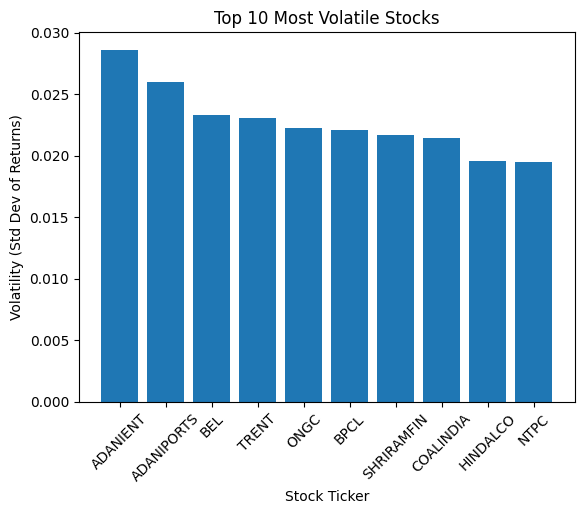

In [31]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(top_volatile["Ticker"], top_volatile["volatility"])

plt.xlabel("Stock Ticker")
plt.ylabel("Volatility (Std Dev of Returns)")
plt.title("Top 10 Most Volatile Stocks")

plt.xticks(rotation=45)

plt.show()

**2. Cumulative Return Over Time:**

In [32]:
df = df.reset_index(drop=True)
df = df.sort_values(by=["Ticker", "date"])

# Calculate daily return (if not already done)
df["prev_close"] = df.groupby("Ticker")["close"].shift(1)
df["daily_return"] = (df["close"] - df["prev_close"]) / df["prev_close"]

# Remove NaN rows (first row of each stock)
df = df.dropna(subset=["daily_return"])
df

,Ticker,close,date,high,low,month,open,volume,prev_close,daily_return
1,ADANIENT,2464.95,2023-10-04,2502.75,2392.25,2023-10,2402.20,2857377,2387.25,0.032548
2,ADANIENT,2466.35,2023-10-05,2486.50,2446.40,2023-10,2477.95,1132455,2464.95,0.000568
3,ADANIENT,2478.10,2023-10-06,2514.95,2466.05,2023-10,2466.35,1510035,2466.35,0.004764
4,ADANIENT,2442.60,2023-10-09,2459.70,2411.30,2023-10,2440.00,1408224,2478.10,-0.014325
5,ADANIENT,2498.30,2023-10-10,2517.95,2443.00,2023-10,2443.00,1771910,2442.60,0.022804
...,...,...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14,574.55,564.20,2024-11,568.95,4891760,569.00,-0.004042
14196,WIPRO,552.85,2024-11-18,566.70,540.30,2024-11,566.70,7644882,566.70,-0.024440
14197,WIPRO,562.00,2024-11-19,569.80,554.70,2024-11,556.00,6459889,552.85,0.016551
14198,WIPRO,557.15,2024-11-21,567.60,555.30,2024-11,562.00,5836304,562.00,-0.008630


In [33]:
df["cumulative_return"] = df.groupby("Ticker")["daily_return"]\
      .transform(lambda x: (1 + x).cumprod() - 1)

final_returns = df.groupby("Ticker")["cumulative_return"].last().reset_index()

top5 = final_returns.sort_values(by="cumulative_return", ascending=False).head(5)

print(top5)

        Ticker  cumulative_return
47       TRENT           2.230926
8          BEL           1.017601
30         M&M           0.959770
5   BAJAJ-AUTO           0.890112
9   BHARTIARTL           0.695990


In [34]:
top5_tickers = top5["Ticker"].tolist()

df_top5 = df[df["Ticker"].isin(top5_tickers)]
df_top5

,Ticker,close,date,high,low,month,open,volume,prev_close,daily_return,cumulative_return
1421,BAJAJ-AUTO,4918.60,2023-10-04,5019.2,4903.05,2023-10,5011.25,256544,5016.45,-0.019506,-0.019506
1422,BAJAJ-AUTO,5011.05,2023-10-05,5039.3,4925.10,2023-10,4935.00,657876,4918.60,0.018796,-0.001076
1423,BAJAJ-AUTO,5014.60,2023-10-06,5120.0,4997.50,2023-10,5120.00,279352,5011.05,0.000708,-0.000369
1424,BAJAJ-AUTO,5007.30,2023-10-09,5068.7,4957.05,2023-10,4957.05,244083,5014.60,-0.001456,-0.001824
1425,BAJAJ-AUTO,5037.50,2023-10-10,5064.0,5002.20,2023-10,5007.30,307502,5007.30,0.006031,0.004196
...,...,...,...,...,...,...,...,...,...,...,...
13627,TRENT,6463.00,2024-11-14,6550.3,6367.05,2024-11,6496.00,620489,6498.25,-0.005425,2.138750
13628,TRENT,6301.65,2024-11-18,6453.0,6275.00,2024-11,6411.60,828906,6463.00,-0.024965,2.060390
13629,TRENT,6423.85,2024-11-19,6579.9,6359.80,2024-11,6359.85,674042,6301.65,0.019392,2.119737
13630,TRENT,6460.45,2024-11-21,6519.0,6346.20,2024-11,6400.00,1511541,6423.85,0.005698,2.137512


C:\Users\Praveen Kumar\AppData\Local\Temp\ipykernel_9132\3643659011.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top5["date"] = pd.to_datetime(df_top5["date"])


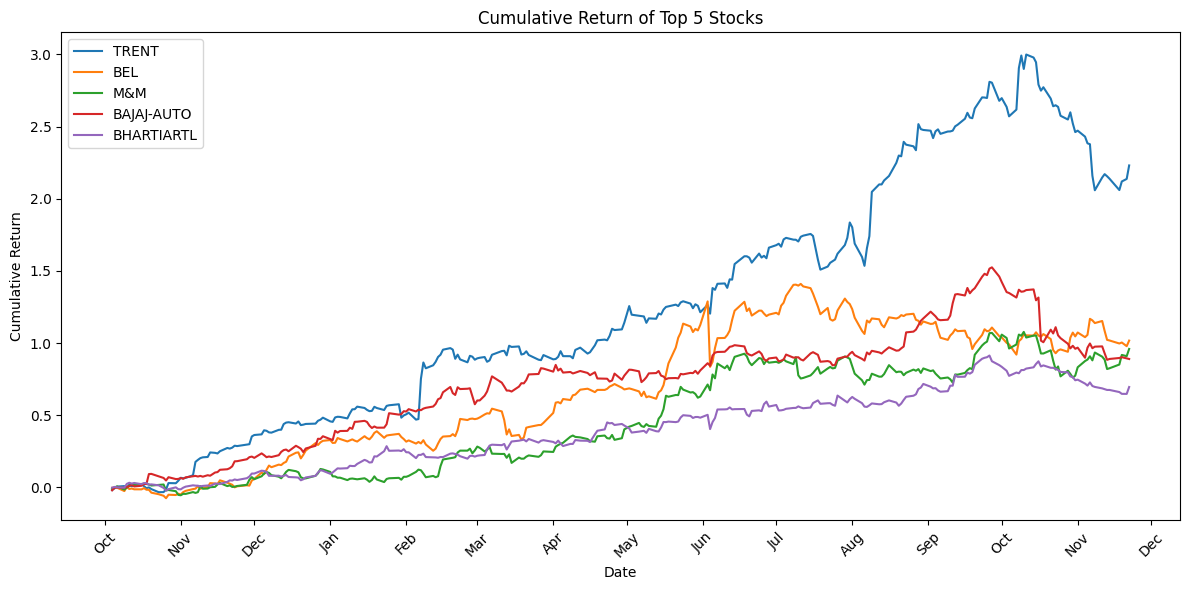

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure date format is correct
df_top5["date"] = pd.to_datetime(df_top5["date"])

plt.figure(figsize=(12,6))

for ticker in top5_tickers:
    temp = df_top5[df_top5["Ticker"] == ticker]
    plt.plot(temp["date"], temp["cumulative_return"], label=ticker)

# ✅ Fix x-axis formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())   # show monthly ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb...

plt.xlabel("Date")   # fixed label typo
plt.ylabel("Cumulative Return")
plt.title("Cumulative Return of Top 5 Stocks")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**3. Sector-wise Performance:**

Sector data cleaning:

In [36]:
sector_df = pd.read_csv("sector_data.csv")
sector_df.columns = sector_df.columns.str.strip().str.lower()
print(sector_df.columns)

Index(['company', 'sector', 'symbol'], dtype='object')


In [37]:
sector_df["Ticker"] = sector_df["symbol"].str.split(":").str[1]

print(sector_df.head())

             company         sector                         symbol  \
0  ADANI ENTERPRISES  MISCELLANEOUS  ADANI ENTERPRISES: ADANIGREEN   
1  ADANI PORTS & SEZ  MISCELLANEOUS  ADANI PORTS & SEZ: ADANIPORTS   
2   APOLLO HOSPITALS  MISCELLANEOUS   APOLLO HOSPITALS: APOLLOHOSP   
3       ASIAN PAINTS         PAINTS       ASIAN PAINTS: ASIANPAINT   
4          AXIS BANK        BANKING            AXIS BANK: AXISBANK   

        Ticker  
0   ADANIGREEN  
1   ADANIPORTS  
2   APOLLOHOSP  
3   ASIANPAINT  
4     AXISBANK  


In [38]:
sector_df["Ticker"] = sector_df["Ticker"].str.strip().str.upper()


In [39]:
sector_df["company"] = sector_df["company"].str.strip().str.upper()
sector_df["sector"] = sector_df["sector"].str.strip().str.upper()

In [40]:
sector_df = sector_df[["Ticker", "sector", "company"]]
print(sector_df.head())

       Ticker         sector            company
0  ADANIGREEN  MISCELLANEOUS  ADANI ENTERPRISES
1  ADANIPORTS  MISCELLANEOUS  ADANI PORTS & SEZ
2  APOLLOHOSP  MISCELLANEOUS   APOLLO HOSPITALS
3  ASIANPAINT         PAINTS       ASIAN PAINTS
4    AXISBANK        BANKING          AXIS BANK


In [41]:
#ticker_fix

sector_df["Ticker"] = sector_df["Ticker"].replace({"ADANIGREEN": "ADANIENT"})

In [43]:
sector_df = sector_df.drop_duplicates(subset="Ticker")

Yearly dataframe cleaning:

In [44]:
yearly=yearly.reset_index()
yearly.head()

,Ticker,first_price,last_price,yearly_return
0,ADANIENT,2387.25,2228.00,-6.670856
1,ADANIPORTS,831.40,1136.75,36.727207
2,APOLLOHOSP,5118.95,6935.10,35.478956
3,ASIANPAINT,3166.85,2472.20,-21.935046
4,AXISBANK,1041.05,1142.40,9.735363


In [45]:
yearly["Ticker"] = yearly["Ticker"].str.strip().str.upper()

In [46]:
sector_performance = pd.merge(
    yearly,
    sector_df,
    left_on="Ticker",
    right_on="Ticker",
    how="left"
)

In [60]:
print(sector_performance.head())
print(sector_performance["sector"].isnull().sum())

       Ticker  first_price  last_price  yearly_return         sector  \
0    ADANIENT      2387.25     2228.00      -6.670856  MISCELLANEOUS   
1  ADANIPORTS       831.40     1136.75      36.727207  MISCELLANEOUS   
2  APOLLOHOSP      5118.95     6935.10      35.478956  MISCELLANEOUS   
3  ASIANPAINT      3166.85     2472.20     -21.935046         PAINTS   
4    AXISBANK      1041.05     1142.40       9.735363        BANKING   

             company  
0  ADANI ENTERPRISES  
1  ADANI PORTS & SEZ  
2   APOLLO HOSPITALS  
3       ASIAN PAINTS  
4          AXIS BANK  
3


In [49]:
sector_avg = sector_performance.groupby("sector")["yearly_return"].mean().reset_index()
sector_avg = sector_avg.sort_values(by="yearly_return", ascending=False)
print(sector_avg)

             sector  yearly_return
16        RETAILING     113.305399
4           DEFENCE     101.760057
15            POWER      60.184095
1       AUTOMOBILES      54.526537
11           MINING      41.846523
17         SOFTWARE      38.275954
3            CEMENT      36.970945
5            ENERGY      36.564788
0         ALUMINIUM      35.868320
19         TEXTILES      35.781988
14  PHARMACEUTICALS      31.379173
12    MISCELLANEOUS      21.845102
18            STEEL      19.217125
6       ENGINEERING      17.253722
10        INSURANCE      11.767832
7           FINANCE      11.576063
2           BANKING      11.380534
9    FOOD & TOBACCO       4.321734
8              FMCG      -0.957916
13           PAINTS     -21.935046


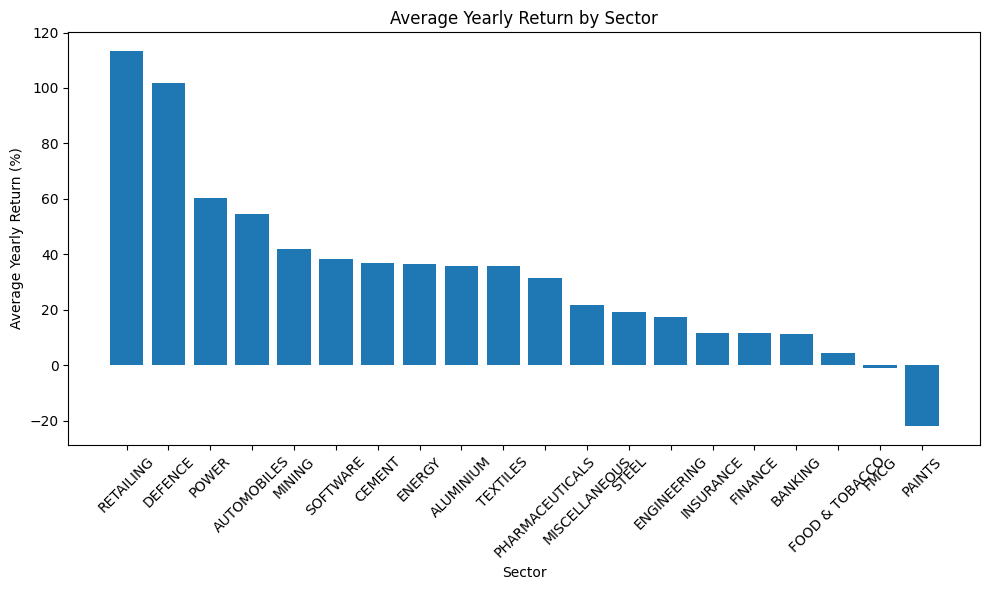

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(sector_avg["sector"], sector_avg["yearly_return"])

plt.xlabel("Sector")
plt.ylabel("Average Yearly Return (%)")
plt.title("Average Yearly Return by Sector")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**4. Stock Price Correlation:**

In [50]:
df.head()

,Ticker,close,date,high,low,month,open,volume,prev_close,daily_return,cumulative_return
1,ADANIENT,2464.95,2023-10-04,2502.75,2392.25,2023-10,2402.20,2857377,2387.25,0.032548,0.032548
2,ADANIENT,2466.35,2023-10-05,2486.50,2446.40,2023-10,2477.95,1132455,2464.95,0.000568,0.033134
3,ADANIENT,2478.10,2023-10-06,2514.95,2466.05,2023-10,2466.35,1510035,2466.35,0.004764,0.038056
4,ADANIENT,2442.60,2023-10-09,2459.70,2411.30,2023-10,2440.00,1408224,2478.10,-0.014325,0.023186
5,ADANIENT,2498.30,2023-10-10,2517.95,2443.00,2023-10,2443.00,1771910,2442.60,0.022804,0.046518


In [51]:
pivot_df = df.pivot(index="date", columns="Ticker", values="close")
pivot_df.head()

Ticker,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BEL,BHARTIARTL,...,SUNPHARMA,TATACONSUM,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
date,,,,,,,,,,,,,,,,,,,,,
2023-10-04,2464.95,824.60,5047.40,3169.90,995.55,4918.60,1532.55,7854.05,138.85,924.25,...,1123.80,854.13,613.60,125.30,3537.75,1205.00,3166.65,2022.30,8120.85,404.90
2023-10-05,2466.35,825.20,5047.05,3206.25,1003.25,5011.05,1542.55,7850.90,138.95,928.85,...,1119.10,849.64,619.60,125.25,3589.35,1205.60,3216.50,2047.60,8177.45,406.80
2023-10-06,2478.10,830.75,5060.25,3195.75,1000.95,5014.60,1634.65,8168.55,139.00,926.05,...,1127.30,864.01,622.45,125.90,3621.40,1216.90,3309.75,2072.10,8195.45,407.85
2023-10-09,2442.60,790.05,5047.30,3152.80,996.25,5007.30,1621.55,8027.70,135.75,924.55,...,1123.05,869.84,617.35,123.85,3638.35,1212.65,3267.50,2079.05,8110.10,405.60
2023-10-10,2498.30,819.50,5066.70,3151.50,1012.25,5037.50,1633.10,8083.60,139.95,948.35,...,1126.50,877.84,630.55,125.30,3628.90,1227.75,3269.20,2050.80,8158.30,407.75


In [52]:
returns_df = pivot_df.pct_change()
returns_df.head()

Ticker,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BEL,BHARTIARTL,...,SUNPHARMA,TATACONSUM,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
date,,,,,,,,,,,,,,,,,,,,,
2023-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-05,0.000568,0.000728,-0.000069,0.011467,0.007734,0.018796,0.006525,-0.000401,0.000720,0.004977,...,-0.004182,-0.005257,0.009778,-0.000399,0.014586,0.000498,0.015742,0.012511,0.006970,0.004693
2023-10-06,0.004764,0.006726,0.002615,-0.003275,-0.002293,0.000708,0.059706,0.040460,0.000360,-0.003014,...,0.007327,0.016913,0.004600,0.005190,0.008929,0.009373,0.028991,0.011965,0.002201,0.002581
2023-10-09,-0.014325,-0.048992,-0.002559,-0.013440,-0.004696,-0.001456,-0.008014,-0.017243,-0.023381,-0.001620,...,-0.003770,0.006748,-0.008193,-0.016283,0.004681,-0.003492,-0.012765,0.003354,-0.010414,-0.005517
2023-10-10,0.022804,0.037276,0.003844,-0.000412,0.016060,0.006031,0.007123,0.006963,0.030939,0.025742,...,0.003072,0.009197,0.021382,0.011708,-0.002597,0.012452,0.000520,-0.013588,0.005943,0.005301


In [53]:
corr_matrix = returns_df.corr()

print(corr_matrix.head())

Ticker      ADANIENT  ADANIPORTS  APOLLOHOSP  ASIANPAINT  AXISBANK  \
Ticker                                                               
ADANIENT    1.000000    0.877940    0.141429    0.291699  0.314322   
ADANIPORTS  0.877940    1.000000    0.167875    0.274304  0.382357   
APOLLOHOSP  0.141429    0.167875    1.000000    0.259123  0.171401   
ASIANPAINT  0.291699    0.274304    0.259123    1.000000  0.129305   
AXISBANK    0.314322    0.382357    0.171401    0.129305  1.000000   

Ticker      BAJAJ-AUTO  BAJAJFINSV  BAJFINANCE       BEL  BHARTIARTL  ...  \
Ticker                                                                ...   
ADANIENT      0.207930    0.363743    0.340741  0.524838    0.284449  ...   
ADANIPORTS    0.203428    0.397626    0.398257  0.585569    0.316344  ...   
APOLLOHOSP    0.220210    0.245657    0.220590  0.224209    0.236449  ...   
ASIANPAINT    0.168736    0.249502    0.297755  0.157085    0.147084  ...   
AXISBANK      0.189184    0.387247    0.350869 

In [89]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


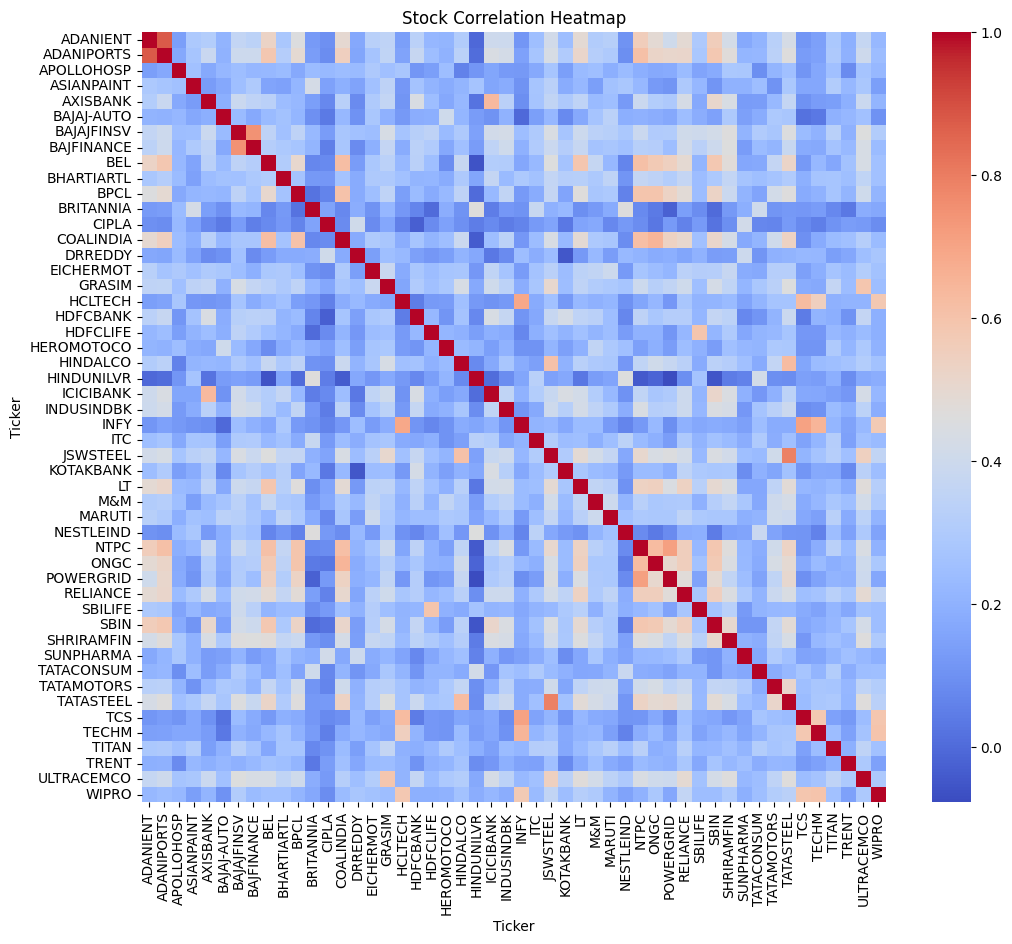

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

plt.title("Stock Correlation Heatmap")
plt.show()

**5. Top 5 Gainers and Losers (Month-wise):**

In [68]:
df["date"] = pd.to_datetime(df["date"])
df["Ticker"] = df["Ticker"].str.strip().str.upper()
df = df.sort_values(["Ticker", "date"])
df["Month"] = df["date"].dt.to_period("M")
df

,Ticker,close,date,high,low,month,open,volume,prev_close,daily_return,cumulative_return,Month
1,ADANIENT,2464.95,2023-10-04,2502.75,2392.25,2023-10,2402.20,2857377,2387.25,0.032548,0.032548,2023-10
2,ADANIENT,2466.35,2023-10-05,2486.50,2446.40,2023-10,2477.95,1132455,2464.95,0.000568,0.033134,2023-10
3,ADANIENT,2478.10,2023-10-06,2514.95,2466.05,2023-10,2466.35,1510035,2466.35,0.004764,0.038056,2023-10
4,ADANIENT,2442.60,2023-10-09,2459.70,2411.30,2023-10,2440.00,1408224,2478.10,-0.014325,0.023186,2023-10
5,ADANIENT,2498.30,2023-10-10,2517.95,2443.00,2023-10,2443.00,1771910,2442.60,0.022804,0.046518,2023-10
...,...,...,...,...,...,...,...,...,...,...,...,...
14195,WIPRO,566.70,2024-11-14,574.55,564.20,2024-11,568.95,4891760,569.00,-0.004042,0.397706,2024-11
14196,WIPRO,552.85,2024-11-18,566.70,540.30,2024-11,566.70,7644882,566.70,-0.024440,0.363547,2024-11
14197,WIPRO,562.00,2024-11-19,569.80,554.70,2024-11,556.00,6459889,552.85,0.016551,0.386114,2024-11
14198,WIPRO,557.15,2024-11-21,567.60,555.30,2024-11,562.00,5836304,562.00,-0.008630,0.374152,2024-11


In [71]:
monthly = df.groupby(["Ticker", "Month"]).agg(
    first_price=("close", "first"),
    last_price=("close", "last")
).reset_index()


monthly["monthly_return"] = (
    (monthly["last_price"] - monthly["first_price"]) / monthly["first_price"]
) * 100

months = sorted(monthly["Month"].astype(str).unique())

print(monthly.head())

     Ticker    Month  first_price  last_price  monthly_return
0  ADANIENT  2023-10      2464.95     2294.65       -6.908862
1  ADANIENT  2023-11      2217.30     2358.55        6.370360
2  ADANIENT  2023-12      2362.70     2848.95       20.580268
3  ADANIENT  2024-01      2917.20     3142.00        7.706019
4  ADANIENT  2024-02      3153.50     3285.40        4.182654


IndexError: index 12 is out of bounds for axis 0 with size 12

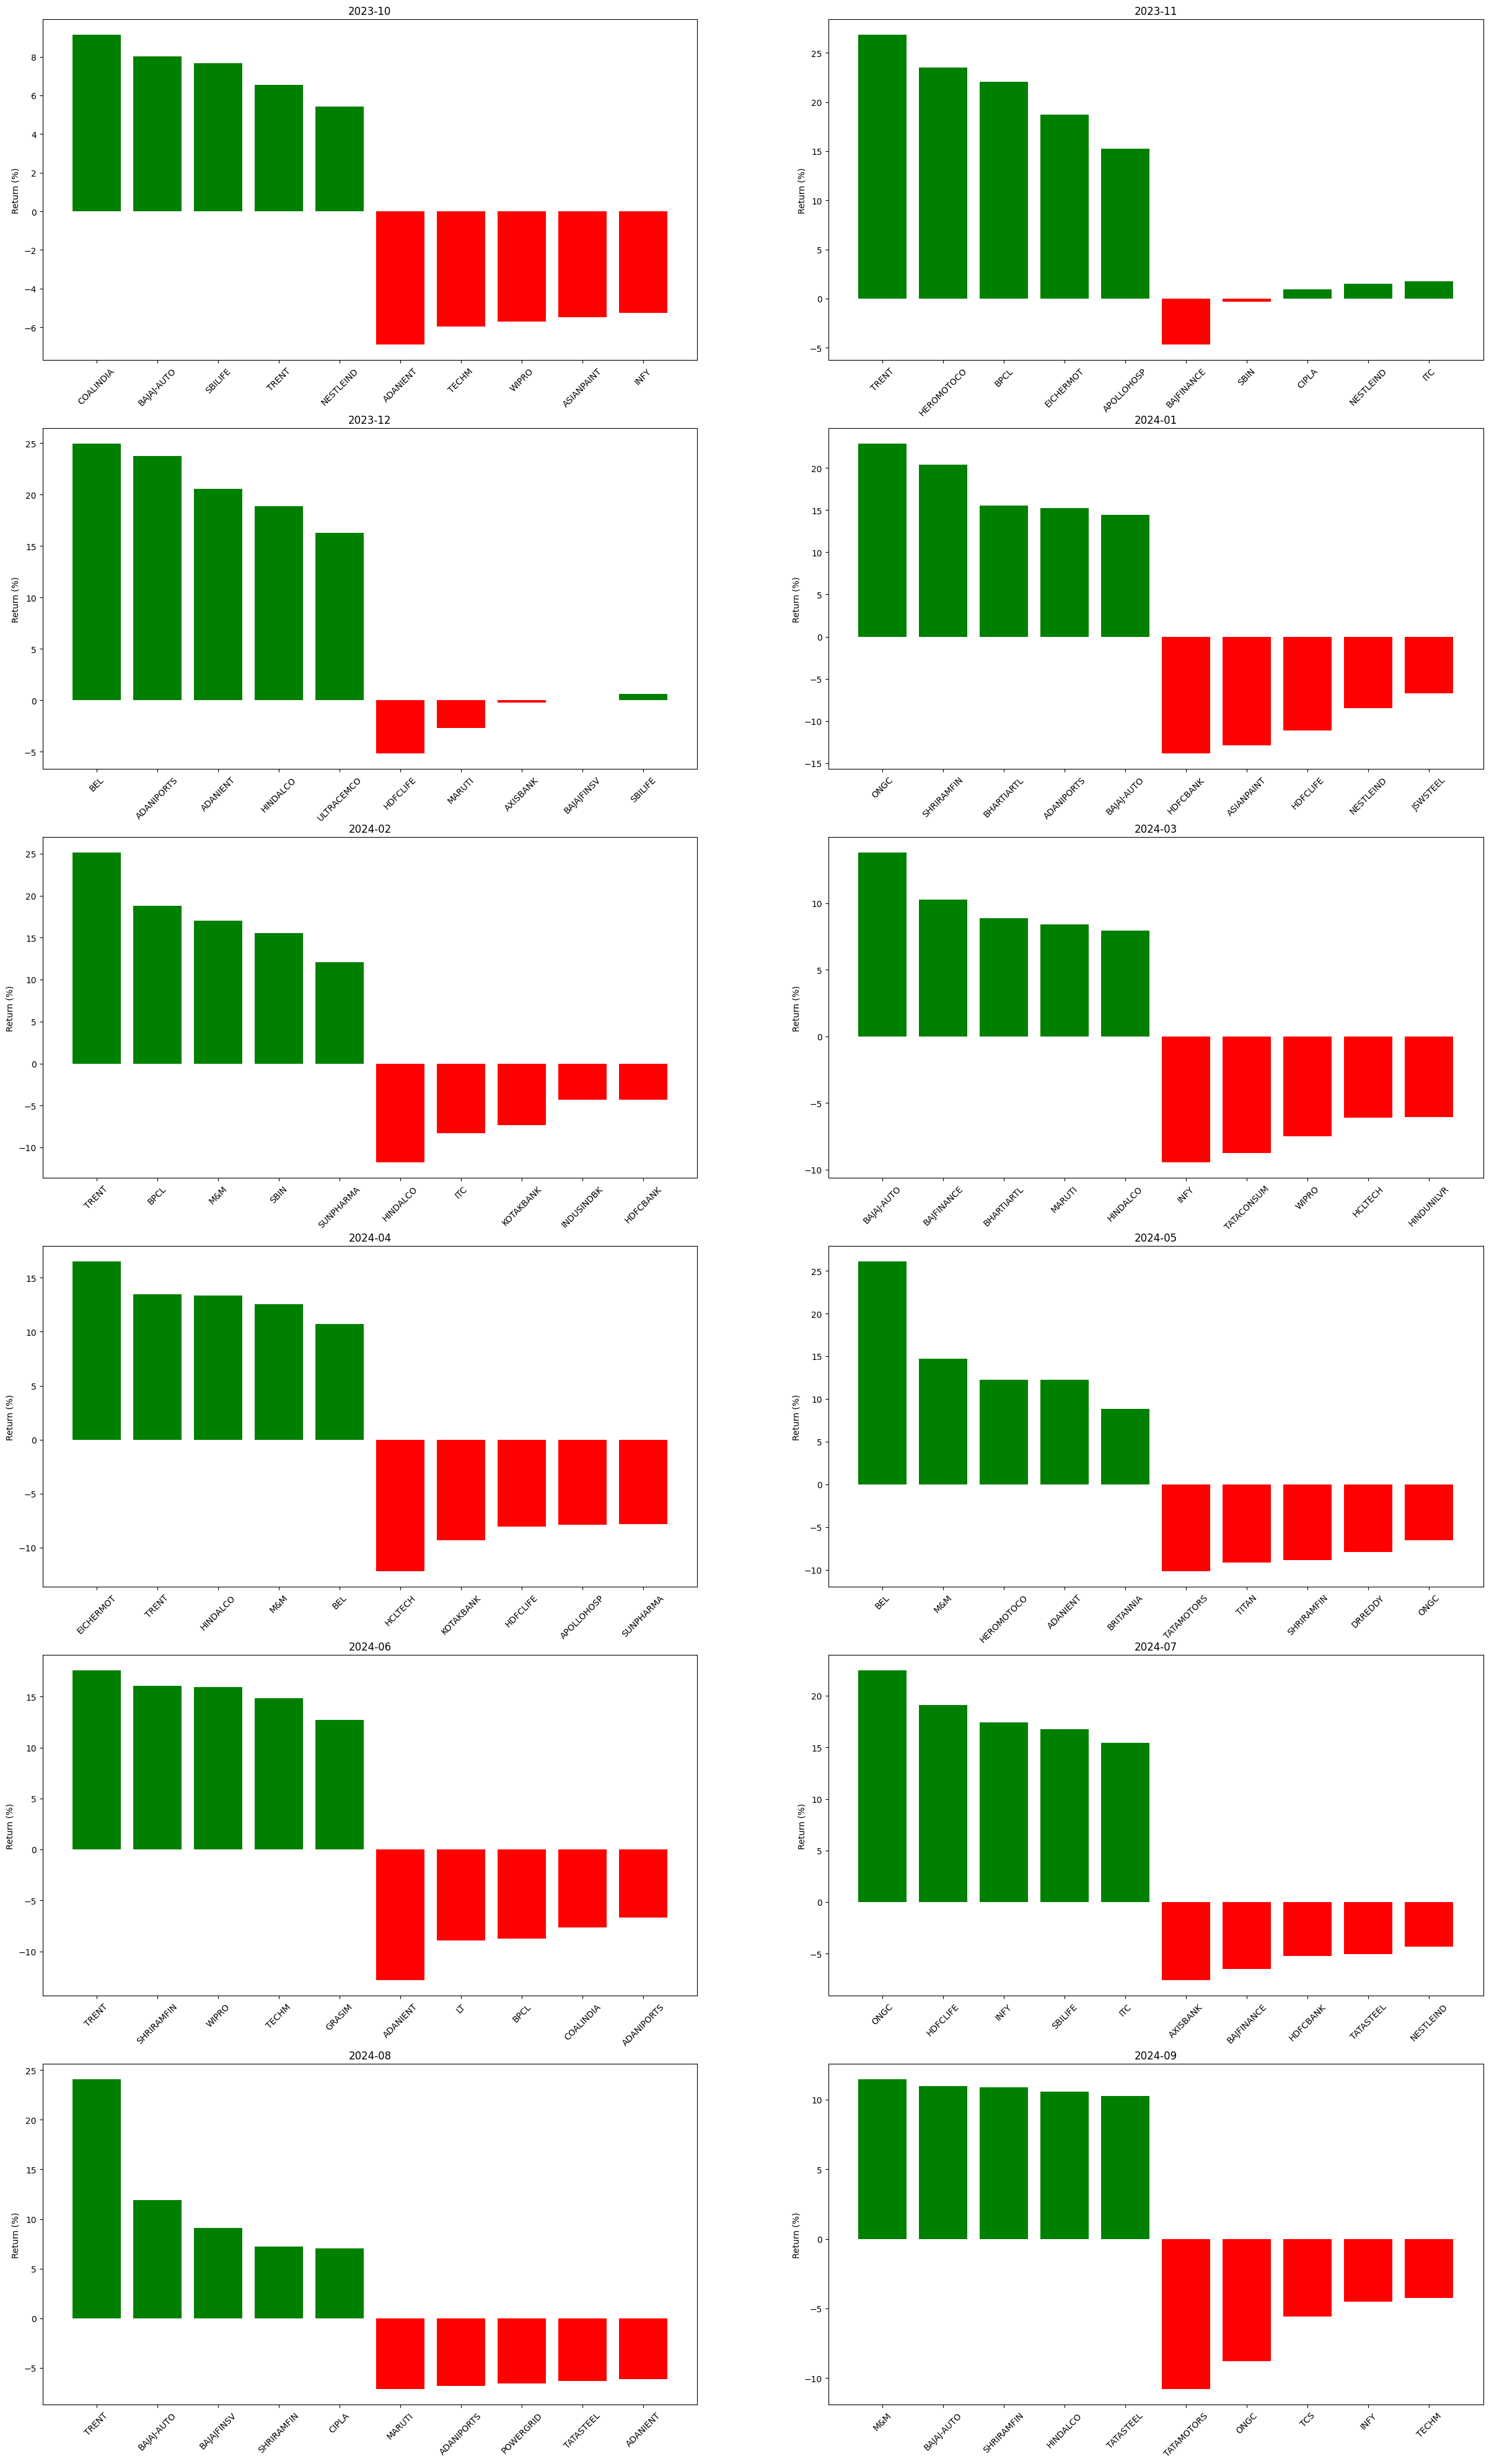

In [73]:
months = sorted(monthly["Month"].astype(str).unique())

fig, axes = plt.subplots(6, 2, figsize=(30, 50))  # 12 charts
axes = axes.flatten()

for i, month in enumerate(months):
    ax = axes[i]

    month_data = monthly[monthly["Month"].astype(str) == month]

    # Top 5 Gainers
    top5 = month_data.sort_values(by="monthly_return", ascending=False).head(5)

    # Top 5 Losers
    bottom5 = month_data.sort_values(by="monthly_return").head(5)

    # Combine both
    combined = pd.concat([top5, bottom5])

    # Colors (Green for gainers, Red for losers)
    colors = ["green" if x > 0 else "red" for x in combined["monthly_return"]]

    # Plot
    ax.bar(combined["Ticker"], combined["monthly_return"], color=colors)

    ax.set_title(f"{month}")
    ax.set_ylabel("Return (%)")
    ax.tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**SQL for Visualization**

In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Connection (XAMPP MySQL)
engine = create_engine("mysql+pymysql://root:@localhost/stock_market")

In [10]:
import mysql.connector


mydb = mysql.connector.connect(host="localhost",user="root",password="")
print(mydb)
mycursor = mydb.cursor(buffered=True)


In [11]:
mycursor.execute("CREATE DATABASE stock_market")

In [6]:
df = pd.read_csv("combined_stock_data.csv")

In [8]:
df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])

In [12]:
df.to_sql("stock_data", con=engine, if_exists="replace", index=False)

14200

In [61]:
print(sector_performance.shape)
print(sector_performance.head())

(50, 6)
       Ticker  first_price  last_price  yearly_return         sector  \
0    ADANIENT      2387.25     2228.00      -6.670856  MISCELLANEOUS   
1  ADANIPORTS       831.40     1136.75      36.727207  MISCELLANEOUS   
2  APOLLOHOSP      5118.95     6935.10      35.478956  MISCELLANEOUS   
3  ASIANPAINT      3166.85     2472.20     -21.935046         PAINTS   
4    AXISBANK      1041.05     1142.40       9.735363        BANKING   

             company  
0  ADANI ENTERPRISES  
1  ADANI PORTS & SEZ  
2   APOLLO HOSPITALS  
3       ASIAN PAINTS  
4          AXIS BANK  


In [62]:
sector_performance.columns = sector_performance.columns.str.strip().str.replace(" ", "_")

In [63]:
sector_performance.to_sql(
    name="sector_data",
    con=engine,
    if_exists="replace",   # replaces table if already exists
    index=False
)

50

In [64]:
import pandas as pd

test = pd.read_sql("SELECT * FROM sector_data LIMIT 5", engine)
print(test)

       Ticker  first_price  last_price  yearly_return         sector  \
0    ADANIENT      2387.25     2228.00      -6.670856  MISCELLANEOUS   
1  ADANIPORTS       831.40     1136.75      36.727207  MISCELLANEOUS   
2  APOLLOHOSP      5118.95     6935.10      35.478956  MISCELLANEOUS   
3  ASIANPAINT      3166.85     2472.20     -21.935046         PAINTS   
4    AXISBANK      1041.05     1142.40       9.735363        BANKING   

             company  
0  ADANI ENTERPRISES  
1  ADANI PORTS & SEZ  
2   APOLLO HOSPITALS  
3       ASIAN PAINTS  
4          AXIS BANK  
